In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

loading cleaned version

In [13]:
df_usd_inr=pd.read_pickle("df_usd_inr.pkl")
df_cpi=pd.read_pickle("df_cpi.pkl")
df_cpi_usa=pd.read_pickle("df_cpi_usa.pkl")

aligning date columns

In [14]:
df_cpi['date'] = pd.to_datetime(df_cpi['date'])
df_usd_inr['Date'] = pd.to_datetime(df_usd_inr['Date'])
df_cpi_usa['DATE'] = pd.to_datetime(df_cpi_usa['DATE'])

merging datasets

In [15]:
df = df_cpi.merge(df_usd_inr, left_on='date', right_on='Date', how='inner')
df = df.merge(df_cpi_usa, left_on='date', right_on='DATE', how='inner')

In [16]:
print(df.shape)

(219, 40)


creating inflation regime : It shows the average USD/INR exchange rate for each inflation level (low, medium, high), helping you see how the currency behaves under different inflation conditions.

In [17]:
df['inflation_regime'] = pd.qcut(
    df['general_index'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

comparing USD/INR with inflation

In [18]:
print(df.groupby('inflation_regime')['Close'].mean())

inflation_regime
Low       61.162699
Medium    66.400242
High      72.490213
Name: Close, dtype: float64


Anova Test : ANOVA tests if the mean USD/INR values across different inflation regimes are significantly different.

In [19]:
low = df[df['inflation_regime'] == 'Low']['Close']
medium = df[df['inflation_regime'] == 'Medium']['Close']
high = df[df['inflation_regime'] == 'High']['Close']

f_stat, p_value = f_oneway(low, medium, high)

print("F-stat:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Significant difference between regimes")
else:
    print("No significant difference")

F-stat: 290.2300682651476
p-value: 6.241491505930516e-62
Significant difference between regimes


visualization : The boxplot visually compares the distribution of USD/INR across inflation regimes, showing differences in median and variability.

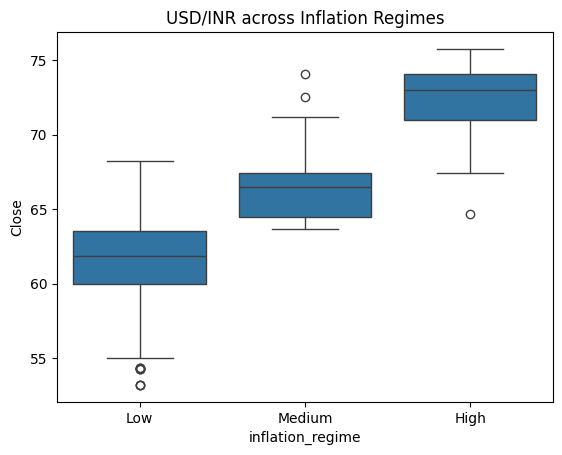

In [20]:
sns.boxplot(x='inflation_regime', y='Close', data=df)
plt.title("USD/INR across Inflation Regimes")
plt.show()